Optimized model parameters:
Theta_(D/E)=326.507527
beta_1=0.009700
beta_2=0.041139
tau=1756.469292
gamma=47.668649
RSE: 2.7742 J/mol/K


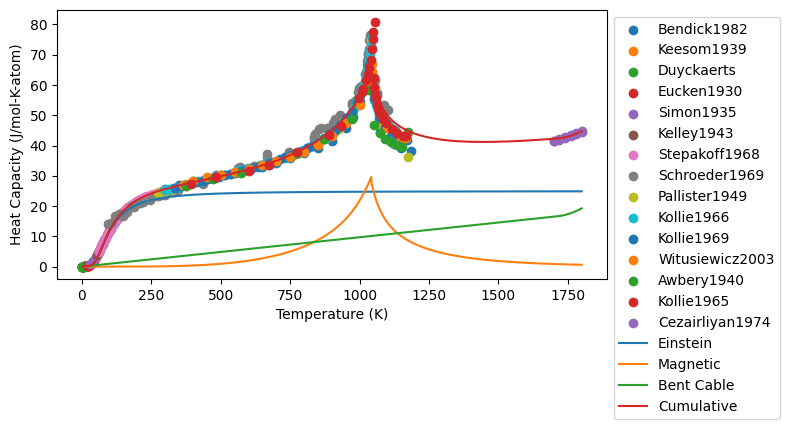

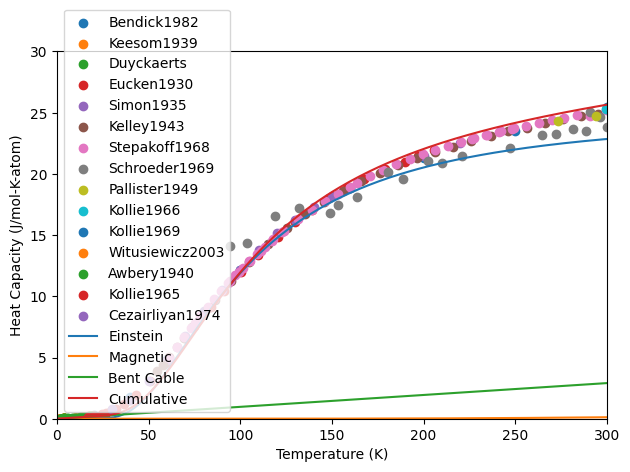

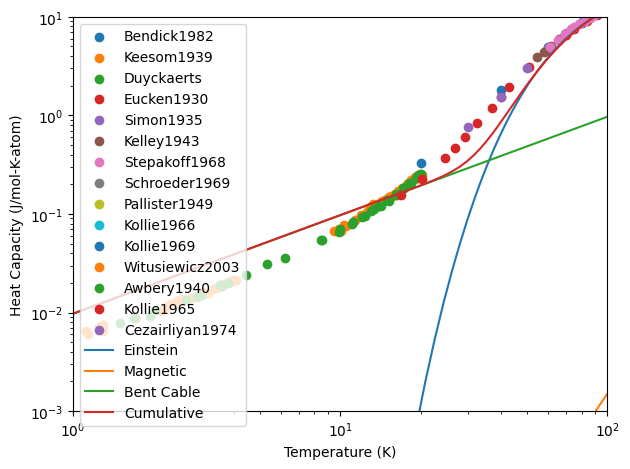

In [1]:
# Example of libreCalphad's heat capacity fitting routines and use of the segmented
# regression approach to model the Gibb's energy for creating custom reference
# states for pycalphad using ESPEI.

# Pycalphad has not implemented the Holzapfel approximation to the Debye model, so generating parameters
# for use with it should be done with the Einstein model for now.

import json
import espei  # required to resolve a circular import caused by next line
from libreCalphad.models.segmented_regression import _bent_cable_Cp, _debye_Cp, _einstein_Cp, _holzapfel_debye_Cp, _xiong_Cp, fit_segmented_regression, get_segmented_regression_Cp, upsert_custom_refstate_json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pycalphad import variables as v

R = 8.314472
# magnetic model constants
beta_Fe = 2.22  # magnetic moment per atom Fe
struct_fact_bcc = 0.37
Tc_Fe = 1043  # K, Curie temperature for Fe
theta_Fe = 309  # K, Einstein temperature from Chen & Sundman
espei_datasets_folder = "/Users/mattfrichtl/opt/ESPEI-datasets/datasets"
xiong_params = {"beta": beta_Fe, "p": struct_fact_bcc, "Tc": Tc_Fe}
use_einstein = True
sr_df, min_fits = fit_segmented_regression(espei_datasets_folder, ["FE", "VA"], "BCC_A2", use_einstein=use_einstein, xiong_params=xiong_params, bounds_overrides={})
# initialize a dataframe for the model
df_model = pd.DataFrame()
df_model["temperature"] = np.linspace(1, np.max(sr_df["temperature"]), num=1000)

print("Optimized model parameters:")
print(f"Theta_(D/E)={min_fits.x[0]:4f}")
print(f"beta_1={min_fits.x[1]:3f}")
print(f"beta_2={min_fits.x[2]:3f}")
print(f"tau={min_fits.x[3]:3f}")
print(f"gamma={min_fits.x[4]:3f}")
print(f"RSE: {min_fits.fun:.4f} J/mol/K")

# Save it to libreCalphad's custom refstate json file
refstate_file = "/Users/mattfrichtl/opt/libreCalphad-refstate/LCRefstates.json"
# Add the fitted refstate results
# Not passing the phase as a kwarg makes libreCalphad assume this is a stable phase Gibbs energy expression
upsert_custom_refstate_json(refstate_file, "FE", min_fits, xiong_params=xiong_params)

# Need to add the lattice stability for FE also, can directly write it to the json
with open(refstate_file, "r") as f:
    refstate_dict = json.load(f)
refstate_dict["FE-BCC_A2"] = "GHSERFE"
with open(refstate_file, "w") as f:
    json.dump(refstate_dict, f, indent=True)
# prepare arrays for plotting
# df_model["debye_model"] = _holzapfel_debye_Cp(df_model["temperature"], *min_fits.x[:1])
df_model["einstein_model"] = _einstein_Cp(df_model["temperature"], theta_Fe)
df_model["magnetic_model"] = _xiong_Cp(
    df_model["temperature"], beta_Fe, struct_fact_bcc, Tc_Fe
)
df_model["bent_cable_model"] = _bent_cable_Cp(df_model["temperature"], *min_fits.x[1:])
df_model["cumulative_model"] = get_segmented_regression_Cp(df_model["temperature"], min_fits, xiong_params=xiong_params, use_einstein=use_einstein)

fig, ax = plt.subplots(figsize=(8,4))
for reference in sr_df["reference"].unique():
    sr_sub = sr_df.query("reference == @reference")
    ax.scatter(sr_sub["temperature"], sr_sub["Cp"], label=reference)
# ax.plot(df_model["temperature"], df_model["debye_model"], label="Debye")
ax.plot(df_model["temperature"], df_model["einstein_model"], label="Einstein")
ax.plot(df_model["temperature"], df_model["magnetic_model"], label="Magnetic")
ax.plot(df_model["temperature"], df_model["bent_cable_model"], label="Bent Cable")
ax.plot(df_model["temperature"], df_model["cumulative_model"], label="Cumulative")
ax.legend(loc="upper left", bbox_to_anchor=(1,1))

ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Heat Capacity (J/mol-K-atom)")
fig.tight_layout()

# < 300 K
fig, ax = plt.subplots()
for reference in sr_df["reference"].unique():
    sr_sub = sr_df.query("reference == @reference")
    ax.scatter(sr_sub["temperature"], sr_sub["Cp"], label=reference)
# ax.plot(df_model["temperature"], df_model["debye_model"], label="Debye")
ax.plot(df_model["temperature"], df_model["einstein_model"], label="Einstein")
ax.plot(df_model["temperature"], df_model["magnetic_model"], label="Magnetic")
ax.plot(df_model["temperature"], df_model["bent_cable_model"], label="Bent Cable")
ax.plot(df_model["temperature"], df_model["cumulative_model"], label="Cumulative")
ax.legend()

ax.set_xlim((0, 300))
ax.set_xlabel("Temperature (K)")
ax.set_ylim((0, 30))
ax.set_ylabel("Heat Capacity (J/mol-K-atom)")
fig.tight_layout()

# Close to 0 K
fig, ax = plt.subplots()
for reference in sr_df["reference"].unique():
    sr_sub = sr_df.query("reference == @reference")
    ax.scatter(sr_sub["temperature"], sr_sub["Cp"], label=reference)
# ax.plot(df_model["temperature"], df_model["debye_model"], label="Debye")
ax.plot(df_model["temperature"], df_model["einstein_model"], label="Einstein")
ax.plot(df_model["temperature"], df_model["magnetic_model"], label="Magnetic")
ax.plot(df_model["temperature"], df_model["bent_cable_model"], label="Bent Cable")
ax.plot(df_model["temperature"], df_model["cumulative_model"], label="Cumulative")
ax.legend()

ax.set_xlim((1e0, 1e2))
ax.set_xscale("log")
ax.set_xlabel("Temperature (K)")
ax.set_ylim((1e-3, 1e1))
ax.set_yscale("log")
ax.set_ylabel("Heat Capacity (J/mol-K-atom)")
fig.tight_layout()

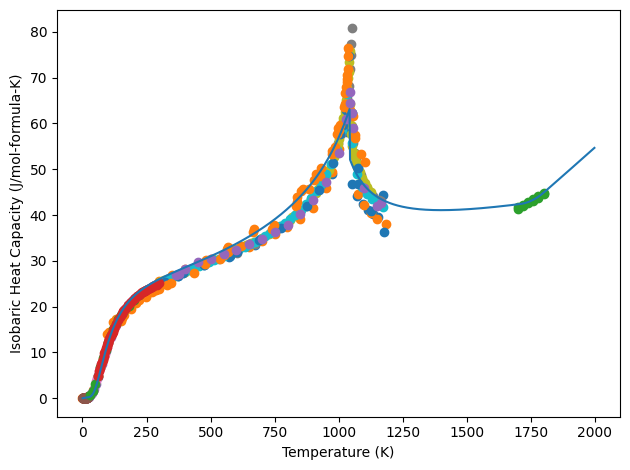

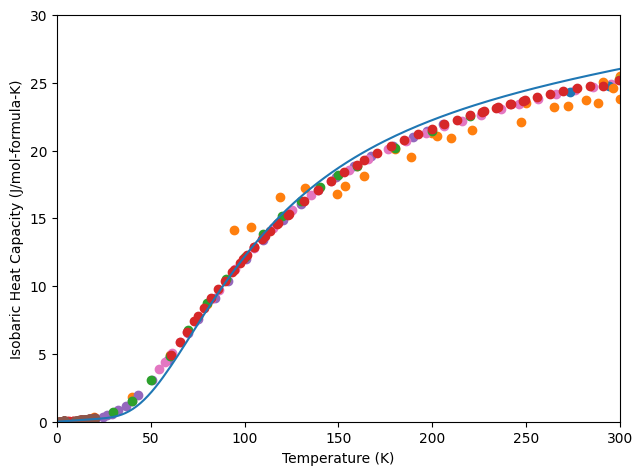

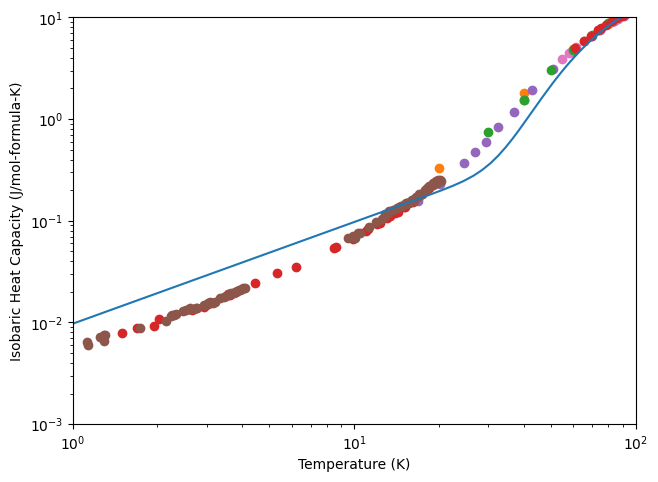

In [2]:
# Use these fits to generate a TDB file with ESPEI and check that pycalphad recreates the heat capacity

from espei.datasets import load_datasets, recursive_glob
import importlib.resources as impresources
from libreCalphad.databases.db_utils import load_database
import matplotlib.pyplot as plt
import numpy as np
from pycalphad import calculate
from tinydb import where
import yaml

dbf = load_database("LC-steels-thermo.tdb")
# Param gen file used to find datasets
param_gen_file = impresources.files("libreCalphad.databases") / "run_param_gen.yaml"
with open(param_gen_file, "r") as f:
    dataset_folder = yaml.safe_load(f)["system"]["datasets"]
datasets = load_datasets(recursive_glob(dataset_folder))
components = ["FE", "VA"]
phase = ["BCC_A2"]

query = (
    (where("phases") == phase)
    & (where("components") == components)
    & (where("output") == "CPM")
)
search_results = datasets.search(query)

fig, ax = plt.subplots()
cpm_res = calculate(
    dbf, components, "BCC_A2", T=(0.5, 2000, 2), P=101325, N=1, output="heat_capacity"
)
ax.plot(cpm_res.T, cpm_res.heat_capacity.squeeze())
for result in search_results:
    ax.scatter(
        result["conditions"]["T"],
        np.array(result["values"]).squeeze(),
        label=result["reference"],
    )
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Isobaric Heat Capacity (J/mol-formula-K)")
fig.tight_layout()

fig, ax = plt.subplots()
cpm_res = calculate(
    dbf, components, "BCC_A2", T=(0.5, 2000, 2), P=101325, N=1, output="heat_capacity"
)
ax.plot(cpm_res.T, cpm_res.heat_capacity.squeeze())
for result in search_results:
    ax.scatter(
        result["conditions"]["T"],
        np.array(result["values"]).squeeze(),
        label=result["reference"],
    )
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Isobaric Heat Capacity (J/mol-formula-K)")
fig.tight_layout()
ax.set_xlim((0, 300))
ax.set_ylim((0,30))

fig, ax = plt.subplots()
cpm_res = calculate(
    dbf, components, "BCC_A2", T=(0.5, 2000, 2), P=101325, N=1, output="heat_capacity"
)
ax.plot(cpm_res.T, cpm_res.heat_capacity.squeeze())
for result in search_results:
    ax.scatter(
        result["conditions"]["T"],
        np.array(result["values"]).squeeze(),
        label=result["reference"],
    )
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Isobaric Heat Capacity (J/mol-formula-K)")
fig.tight_layout()
ax.set_ylim((0, 30))
ax.set_xlim((1e0, 1e2))
ax.set_xscale("log")
ax.set_ylim((1e-3, 1e1))
ax.set_yscale("log")

__SER Energies__
H298: 13245.915285542374
S298: 37.28233807163296


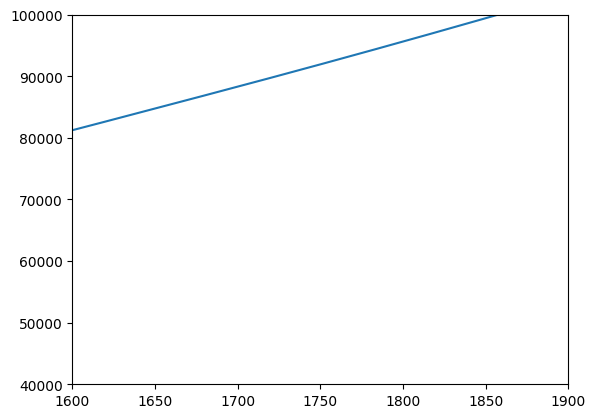

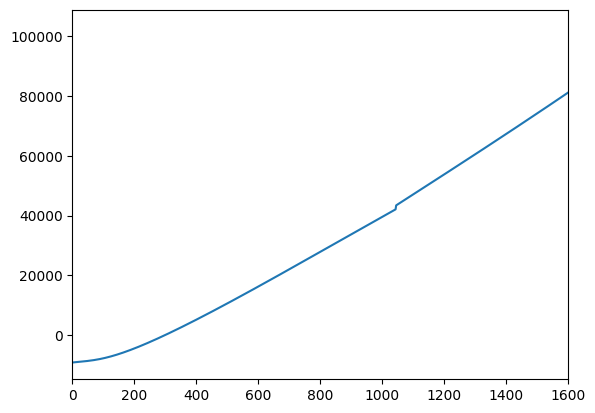

In [9]:
import espei
from libreCalphad.models.segmented_regression import calc_enthalpy, calc_entropy, calc_gibbs_energy, _xiong_enthalpy, _xiong_entropy, _bent_cable_enthalpy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# magnetic model constants
beta_Fe = 2.22  # magnetic moment per atom Fe
struct_fact_bcc = 0.37
Tc_Fe = 1043  # K, Curie temperature for Fe
theta_Fe = 309  # K, Einstein temperature from Chen & Sundman
xiong_params = {"beta": beta_Fe, "p": struct_fact_bcc, "Tc": Tc_Fe}
H298 = calc_enthalpy(298.15, min_fits, xiong_params=xiong_params)
S298 = calc_entropy(298.15, min_fits, xiong_params=xiong_params)
df_model = pd.DataFrame()
df_model["temperature"] = np.linspace(1, 1900, num=1000)

enthalpy = calc_enthalpy(df_model["temperature"], min_fits, xiong_params=xiong_params)
# xiong_enthalpy = _xiong_enthalpy(df_model["temperature"], *list(xiong_params.values()))
# xiong_entropy = _xiong_entropy(df_model["temperature"], *list(xiong_params.values()))
# bc_enthalpy = _bent_cable_enthalpy(df_model["temperature"], *min_fits.x[1:])
entropy = calc_entropy(df_model["temperature"], min_fits, xiong_params=xiong_params)
gibbs = calc_gibbs_energy(df_model["temperature"], min_fits, xiong_params=xiong_params)

fig, ax = plt.subplots()
ax.plot(df_model["temperature"], enthalpy-H298)
ax.set_xlim((1600, 1900))
ax.set_ylim((40000,100000))


fig, ax = plt.subplots()
ax.plot(df_model["temperature"], enthalpy-H298)
ax.set_xlim((0, 1600))

print("__SER Energies__")
print(f"H298: {H298}")
print(f"S298: {S298}")

In [6]:
entropy

array([ 9.73184948,  9.74923703,  9.76710285,  9.78575903,  9.80551464,
        9.82667341,  9.84953398,  9.87439785,  9.9015826 ,  9.93142811,
        9.96428883, 10.00051693, 10.04044639, 10.08438535, 10.13261733,
       10.18540819, 10.24301418, 10.3056875 , 10.3736777 , 10.44722892,
       10.52657399, 10.61192693, 10.70347524, 10.8013732 , 10.90573677,
       11.0166405 , 11.13411637, 11.25815438, 11.38870461, 11.52568024,
       11.66896138, 11.81839912, 11.9738199 , 12.13502958, 12.30181751,
       12.47396017, 12.65122449, 12.83337086, 13.02015571, 13.21133375,
       13.40665994, 13.6058911 , 13.80878729, 14.01511293, 14.22463776,
       14.43713756, 14.65239471, 14.87019869, 15.09034638, 15.31264228,
       15.53689867, 15.76293565, 15.99058118, 16.21967098, 16.45004849,
       16.6815647 , 16.91407799, 17.147454  , 17.38156533, 17.61629142,
       17.85151826, 18.08713818, 18.32304959, 18.55915677, 18.79536958,
       19.03160327, 19.26777819, 19.50381961, 19.73965743, 19.97